# Ejercicios clase 6 — Calibración de modelos (`weatherAUS`)

Dataset climático diario de Australia. La variable objetivo `RainTomorrow` (Sí/No) indica si llovió al día siguiente.
Más info: [Kaggle / weatherAUS limpio](https://www.kaggle.com/datasets/sandhyapalaniappan/rainfall-prediction-dataset-cleaned-weatheraus).

El objetivo de esta práctica **no es clasificar mejor**, sino estudiar la **calibración** de los modelos: ¿las probabilidades que devuelven reflejan frecuencias reales? Si un modelo predice `0.7`, ¿el evento ocurre realmente el 70 % de las veces?

Para medir la calibración usaremos dos herramientas vistas en la teoría:

- **Curva de calibración** (*reliability diagram*): compara la probabilidad predicha (eje X) contra la frecuencia real de positivos (eje Y). Si la curva cae sobre la diagonal, la calibración es perfecta.
- **Brier Score**: $\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(p_i - y_i)^2$. Va de 0 a 1; **0 es lo mejor**. Recordar que se descompone como `Calibración − Discriminación + Ruido`, por lo que comparar el Brier entre modelos **con distinta capacidad de discriminación** no es del todo justo.

Complementamos con **Accuracy** (discriminación) y **Log-loss**.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss

sns.set()

# Ejercicio 1 — Logistic Regression vs Random Forest

## 1.1 Carga, selección de variables y limpieza

In [20]:
weather_df = pd.read_csv("./datasets/weatherAUS.csv")
weather_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2010-04-30,Adelaide,10.8,21.2,0.0,1.8,6.60,ENE,22.0,ENE,...,66.0,48.0,1028.4,1024.7,4.45,4.51,15.7,21.0,No,No
1,2014-07-22,Adelaide,3.7,19.0,0.0,1.4,7.61,N,24.0,N,...,75.0,32.0,1024.2,1021.1,4.45,4.51,9.6,18.5,No,No
2,2014-07-23,Adelaide,9.6,15.8,0.0,2.6,7.61,NE,52.0,NNE,...,35.0,51.0,1017.9,1011.5,4.45,4.51,14.7,15.4,No,Yes
3,2014-07-24,Adelaide,10.1,15.5,16.6,0.8,7.61,NNE,50.0,NW,...,96.0,80.0,1007.4,1008.0,4.45,4.51,11.2,14.0,Yes,Yes
4,2014-07-25,Adelaide,11.2,16.2,1.8,0.6,7.61,NW,30.0,WNW,...,89.0,70.0,1018.4,1019.2,4.45,4.51,13.0,15.3,Yes,Yes


In [21]:
weather_df.shape

(145460, 23)

In [22]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

Seleccionamos un subconjunto de variables numéricas relevantes desde el punto de vista climático (temperatura, lluvia, humedad, presión y viento). El target `RainTomorrow` es categórico (`Yes`/`No`); lo mapeamos a binario `1`/`0`.

| Variable | Descripción |
|---|---|
| `MinTemp` / `MaxTemp` | Temperatura mínima / máxima del día (°C). |
| `Rainfall` | Lluvia registrada en el día (mm). |
| `Humidity9am` / `Humidity3pm` | Humedad relativa a las 9am / 3pm (%). |
| `Pressure9am` / `Pressure3pm` | Presión atmosférica a las 9am / 3pm (hPa). |
| `WindGustSpeed` | Velocidad de la ráfaga de viento más fuerte (km/h). |
| `Temp9am` / `Temp3pm` | Temperatura a las 9am / 3pm (°C). |
| `RainTomorrow` (target) | ¿Llovió al día siguiente? `Yes`/`No` → `1`/`0`. |

In [23]:
features = [
    "MinTemp", "MaxTemp", "Rainfall",
    "Humidity9am", "Humidity3pm",
    "Pressure9am", "Pressure3pm",
    "WindGustSpeed", "Temp9am", "Temp3pm",
]

df = weather_df[features + ["RainTomorrow"]].copy()

# Mapeo del target a binario
df["RainTomorrow"] = df["RainTomorrow"].map({"No": 0, "Yes": 1})

# Limpieza defensiva de faltantes (el dataset ya viene limpio)
df = df.dropna().reset_index(drop=True)
print(f"Shape tras seleccion y limpieza: {df.shape}")
df.head()

Shape tras seleccion y limpieza: (145460, 11)


,MinTemp,MaxTemp,Rainfall,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,WindGustSpeed,Temp9am,Temp3pm,RainTomorrow
0,10.8,21.2,0.0,66.0,48.0,1028.4,1024.7,22.0,15.7,21.0,0
1,3.7,19.0,0.0,75.0,32.0,1024.2,1021.1,24.0,9.6,18.5,0
2,9.6,15.8,0.0,35.0,51.0,1017.9,1011.5,52.0,14.7,15.4,1
3,10.1,15.5,16.6,96.0,80.0,1007.4,1008.0,50.0,11.2,14.0,1
4,11.2,16.2,1.8,89.0,70.0,1018.4,1019.2,30.0,13.0,15.3,1


In [24]:
# Distribucion del target (esperamos desbalance: llueve menos veces de las que no)
df["RainTomorrow"].value_counts(normalize=True)

RainTomorrow
0    0.780854
1    0.219146
Name: proportion, dtype: float64

*Interpretación (completar): ¿qué tan desbalanceado está el target? ¿cómo podría afectar esto a las probabilidades predichas y a su calibración?*

El dataset esta desbalanceado, donde el 20% de files dicen que llueve ma;ana vs, el 80 que dice que no. Es esperable, porque llueve menos veces que las que no. Puede afectar las probabilidad porque el modelo puede ser que mueva las fronteras de decision para un lado u otro esperando separar las clases correctamente, y esto no lleve a la probabilidad real que ya de entrada vemos que es un 20% de que llueva vs el 80% de que no

## 1.2 Separación en entrenamiento y testeo (80 % – 20 %)

In [25]:
X = df[features]
y = df["RainTomorrow"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (116368, 10) | Test: (29092, 10)


## 1.3 Entrenamiento de los dos modelos

- **Logistic Regression**: dentro de un pipeline con `StandardScaler` (la regresión logística necesita features en escala comparable y `max_iter` holgado para converger). Según la teoría, este modelo **está bien calibrado por diseño**, ya que optimiza la log-loss (máxima verosimilitud), alineando sus probabilidades con las frecuencias observadas.
- **Random Forest**: promedia el voto de muchos árboles, lo que tiende a alejar las probabilidades de los extremos 0 y 1 (rara vez todos los árboles votan igual).

In [26]:
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

## 1.4 Probabilidades predichas e histogramas

In [27]:
# Probabilidad de la clase positiva (RainTomorrow = 1)
prob_logreg = logreg.predict_proba(X_test)[:, 1]
prob_rf = rf.predict_proba(X_test)[:, 1]

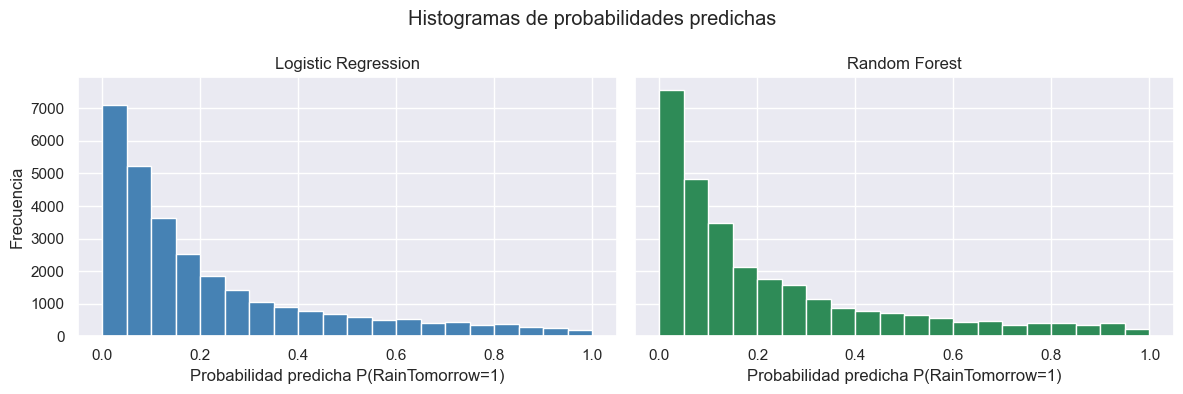

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(prob_logreg, bins=20, range=(0, 1), color="steelblue")
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Probabilidad predicha P(RainTomorrow=1)")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(prob_rf, bins=20, range=(0, 1), color="seagreen")
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Probabilidad predicha P(RainTomorrow=1)")

fig.suptitle("Histogramas de probabilidades predichas")
plt.tight_layout()
plt.show()

*Interpretación (completar): ¿cómo se distribuyen las probabilidades de cada modelo? ¿Alguno evita los valores extremos (cercanos a 0 y 1)? Relacionar con la idea teórica de que el Random Forest "promedia votos".*

Se ven similares, la regesion logistica parece mas baja en el 1, pero se ven muy similares es simple vista. Ninguno evita valores extremos como esperamos para random forest

## 1.5 Curvas de calibración

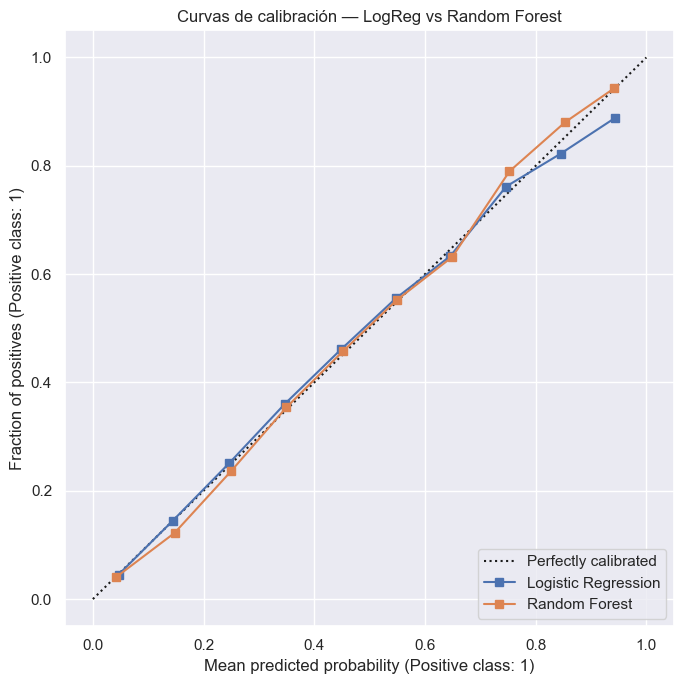

In [29]:
fig, ax = plt.subplots(figsize=(7, 7))

CalibrationDisplay.from_predictions(
    y_test, prob_logreg, n_bins=10, name="Logistic Regression", ax=ax
)
CalibrationDisplay.from_predictions(
    y_test, prob_rf, n_bins=10, name="Random Forest", ax=ax
)

ax.set_title("Curvas de calibración — LogReg vs Random Forest")
plt.tight_layout()
plt.show()

## 1.6 Métricas: Accuracy, Brier Score y Log-loss

In [30]:
metricas_ej1 = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_test, logreg.predict(X_test)),
        accuracy_score(y_test, rf.predict(X_test)),
    ],
    "Brier Score": [
        brier_score_loss(y_test, prob_logreg),
        brier_score_loss(y_test, prob_rf),
    ],
    "Log-loss": [
        log_loss(y_test, prob_logreg),
        log_loss(y_test, prob_rf),
    ],
}, index=["Logistic Regression", "Random Forest"])
metricas_ej1

,Accuracy,Brier Score,Log-loss
Logistic Regression,0.834009,0.119541,0.380786
Random Forest,0.845971,0.110570,0.359384


*Interpretación (completar): según la curva de calibración y las métricas, ¿cuál modelo parece mejor calibrado? ¿Coincide con lo que predice la teoría sobre la regresión logística? Tener presente que el Brier Score mezcla calibración y discriminación (`Brier = Calibración − Discriminación + Ruido`), por lo que compararlo entre dos modelos distintos hay que hacerlo con cuidado.*

Ambos modelos se ven bien calibrados y predicen probabilidades reales. Hubiera esperado que random forest no estuviera bien calibrado pero podemos ver que para nuestro ejemplo funciono bien por lo que no es ncesario hacer un proceso de calibracion posterior, ya que el modelo por si solo ya esta correcto

# Ejercicio 2 — GaussianNB y su calibración

## 2.1 Entrenamiento de GaussianNB (sin calibrar)

Reutilizamos el mismo split (`X_train`, `X_test`, ...) del Ejercicio 1. Según la teoría, Naive Bayes tiende a producir **probabilidades ingenuas**: al asumir que todas las features son independientes, "infla" la evidencia y empuja las probabilidades hacia los extremos (cerca de 0 o 1).

In [31]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

prob_gnb = gnb.predict_proba(X_test)[:, 1]

## 2.2 Histograma y curva de calibración del modelo sin calibrar

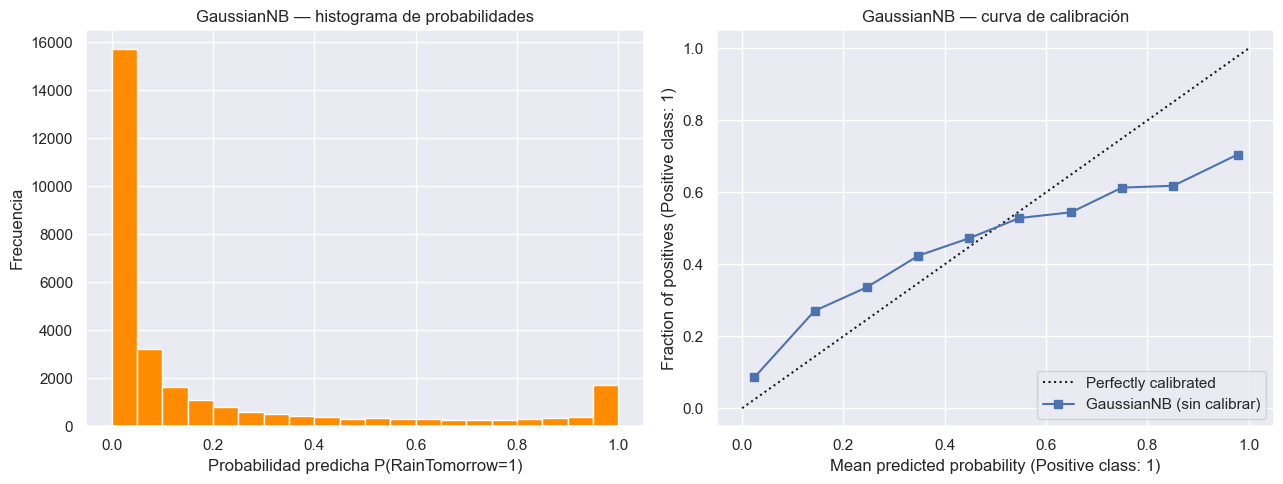

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(prob_gnb, bins=20, range=(0, 1), color="darkorange")
axes[0].set_title("GaussianNB — histograma de probabilidades")
axes[0].set_xlabel("Probabilidad predicha P(RainTomorrow=1)")
axes[0].set_ylabel("Frecuencia")

CalibrationDisplay.from_predictions(
    y_test, prob_gnb, n_bins=10, name="GaussianNB (sin calibrar)", ax=axes[1]
)
axes[1].set_title("GaussianNB — curva de calibración")

plt.tight_layout()
plt.show()

*Interpretación (completar): ¿se observa el efecto de "probabilidades ingenuas" en el histograma (acumulación cerca de 0 y 1)? ¿Cómo se desvía la curva de la diagonal?*

Con NB si se observa que cerca del 0 y del 1 tenemos la mayor cantidad de predicciones. Ademas podemos ver en la curva de calibracion que se sale de la diagonal bastante, prediciendo probabilidades que no son las reales, con una mayor confianza en los valores bajos y una menos confianza en los valores altos.

## 2.3 Calibración con `CalibratedClassifierCV` (sigmoid e isotonic)

- **`sigmoid`** = *Platt Scaling*: ajusta una regresión logística sobre el score del modelo. Funciona bien con pocos datos.
- **`isotonic`** = regresión isotónica: método no paramétrico (algoritmo PAVA) que aprende una función escalonada monótona creciente. Se ajusta a cualquier forma, pero necesita más datos para no sobreajustar.

Usamos `cv=5`: el calibrador se entrena por validación cruzada para evitar overfitting (no reutiliza los mismos datos con que se entrenó el modelo base).

In [33]:
gnb_sigmoid = CalibratedClassifierCV(GaussianNB(), method="sigmoid", cv=5)
gnb_sigmoid.fit(X_train, y_train)

gnb_isotonic = CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5)
gnb_isotonic.fit(X_train, y_train)

prob_sigmoid = gnb_sigmoid.predict_proba(X_test)[:, 1]
prob_isotonic = gnb_isotonic.predict_proba(X_test)[:, 1]

## 2.4 Curvas de calibración de los tres modelos y comparación de Brier Score

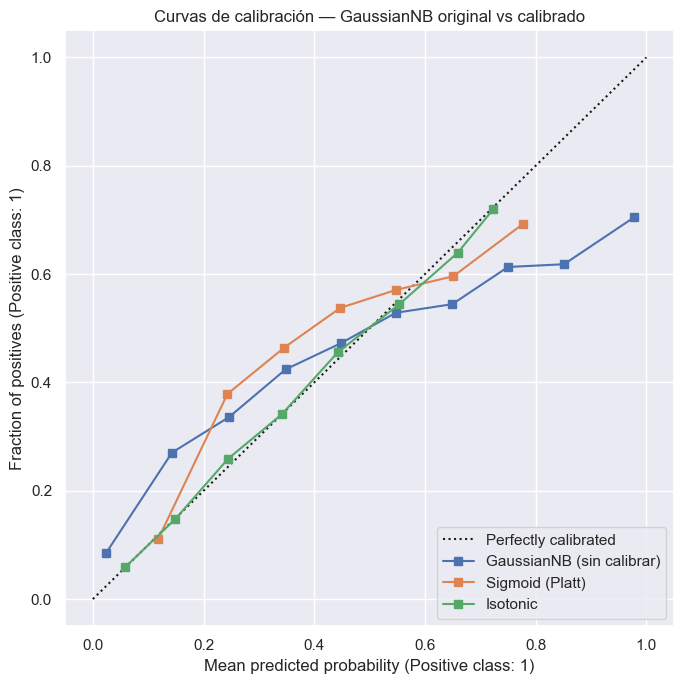

In [34]:
fig, ax = plt.subplots(figsize=(7, 7))

CalibrationDisplay.from_predictions(
    y_test, prob_gnb, n_bins=10, name="GaussianNB (sin calibrar)", ax=ax
)
CalibrationDisplay.from_predictions(
    y_test, prob_sigmoid, n_bins=10, name="Sigmoid (Platt)", ax=ax
)
CalibrationDisplay.from_predictions(
    y_test, prob_isotonic, n_bins=10, name="Isotonic", ax=ax
)

ax.set_title("Curvas de calibración — GaussianNB original vs calibrado")
plt.tight_layout()
plt.show()

In [35]:
# Aca la comparacion de Brier SI es valida: mismo modelo base (GaussianNB),
# misma discriminacion; solo cambia la calibracion.
metricas_ej2 = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_test, gnb.predict(X_test)),
        accuracy_score(y_test, gnb_sigmoid.predict(X_test)),
        accuracy_score(y_test, gnb_isotonic.predict(X_test)),
    ],
    "Brier Score": [
        brier_score_loss(y_test, prob_gnb),
        brier_score_loss(y_test, prob_sigmoid),
        brier_score_loss(y_test, prob_isotonic),
    ],
    "Log-loss": [
        log_loss(y_test, prob_gnb),
        log_loss(y_test, prob_sigmoid),
        log_loss(y_test, prob_isotonic),
    ],
}, index=["GaussianNB (sin calibrar)", "Sigmoid (Platt)", "Isotonic"])
metricas_ej2

,Accuracy,Brier Score,Log-loss
GaussianNB (sin calibrar),0.823010,0.138822,0.611987
Sigmoid (Platt),0.821222,0.131654,0.420684
Isotonic,0.822494,0.126650,0.401598


*Interpretación (completar): ¿qué método de calibración (`sigmoid` o `isotonic`) funcionó mejor según el Brier Score y la curva de calibración? ¿El Accuracy cambió luego de calibrar? Relacionar con la idea de que la calibración no busca clasificar mejor, sino medir bien la incertidumbre.*

El accuracy no cambio porque la calibracion no cambia el accuracy, solo busca medir bien la incertidumbre y que esto sea real con lo esperado para una probabilidad.

Vemos que el metodo que mejor funciono es el isotonic, con un brier score de 0.126 vs 0.132 de la sigmoid, y como vemos en el grafico de la curva de calibracion, la isotonic esta mucho mas pegada a la diagonal, por lo que logra una mejor calibracion. Esto se podria explicar en que NB empuja mucho a los bordes en 0 y 1, a lo que una sigmoide no llega a poder explicar correctamente esos datos, que una regresion isonotica puede hacer varios bin sobre los datos y lograr representar mejor la linealidad de los datos en bins, lo cual logra explicar mejor los datos y darnos una mejor relacion entre las probabilidad que entrega el modelo y las reales